# Day 4 – Fund Performance Analytics

This notebook focuses on evaluating mutual fund performance using return and risk-based metrics. Daily returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown are computed to assess fund performance and risk-adjusted returns. A composite fund scorecard is also developed to rank funds based on multiple performance indicators. Fund returns are compared against benchmark indices to evaluate relative performance.

In [54]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

import os

os.makedirs("../reports/charts", exist_ok=True)

In [55]:
nav = pd.read_csv(
    "../data/raw/02_nav_history.csv"
)

performance = pd.read_csv(
    "../data/raw/07_scheme_performance.csv"
)

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

funds = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

print("Datasets loaded successfully")

Datasets loaded successfully


In [56]:
print(nav.shape)
print(performance.shape)
print(benchmark.shape)

print(nav.columns)
print(performance.columns)
print(benchmark.columns)

(46000, 3)
(40, 19)
(8050, 3)
Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')
Index(['date', 'index_name', 'close_value'], dtype='str')


## Daily Return Calculation

Daily returns are calculated using the percentage change in NAV between consecutive trading days.

Formula:

Daily Return = (NAVt / NAVt-1) - 1

These returns form the foundation for all subsequent risk and performance calculations.

In [57]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


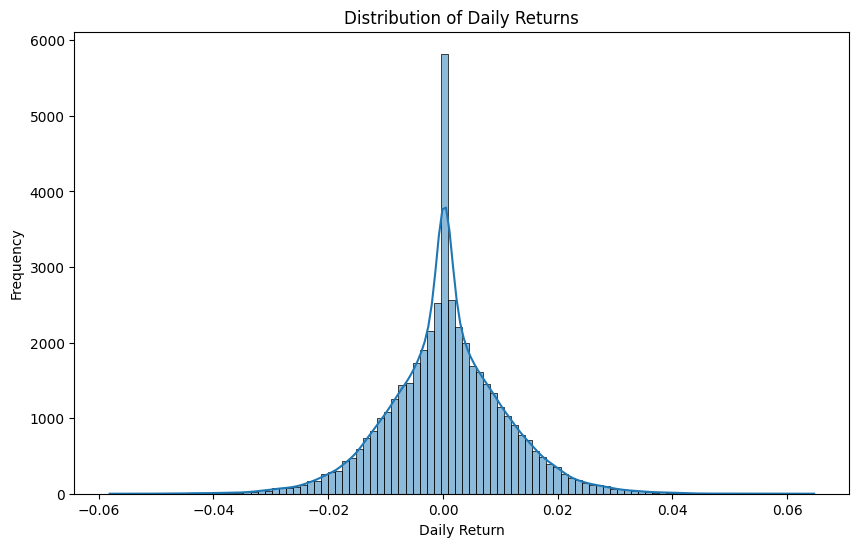

In [58]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.savefig(
    "../reports/charts/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 1

Daily returns are concentrated around zero with relatively few extreme observations, indicating realistic market behaviour and suitable data quality for risk metric calculations.

**Reference:** Daily Return Distribution

## CAGR Analysis

Compound Annual Growth Rate (CAGR) measures the annualized growth of an investment over a specified period.

Formula:

CAGR = (Ending Value / Beginning Value)^(1/n) - 1

In [59]:
cagr_table = performance[
    [
        "amfi_code",
        "scheme_name",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct"
    ]
]

cagr_table = cagr_table.rename(
    columns={
        "return_1yr_pct":"CAGR_1Y",
        "return_3yr_pct":"CAGR_3Y",
        "return_5yr_pct":"CAGR_5Y"
    }
)

cagr_table.head()


,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,119552,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,119598,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,119599,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


In [60]:
cagr_table.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

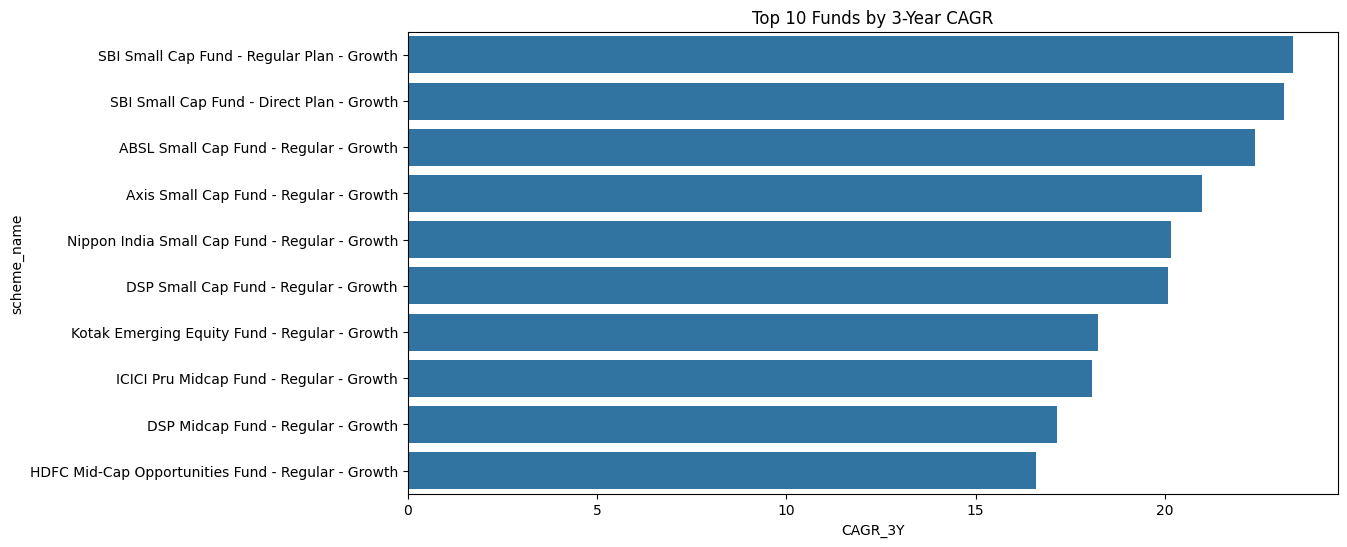

In [61]:
top_cagr = (
    cagr_table
    .sort_values(
        "CAGR_3Y",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_cagr,
    x="CAGR_3Y",
    y="scheme_name"
)

plt.title("Top 10 Funds by 3-Year CAGR")

plt.savefig(
    "../reports/charts/top10_cagr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 2

Several funds generated strong annualized returns over the three-year period, demonstrating superior long-term performance relative to peers.

**Reference:** Top 10 Funds by 3-Year CAGR

## Sharpe Ratio

Sharpe Ratio measures risk-adjusted returns by comparing excess returns over the risk-free rate against overall volatility.

Risk-Free Rate Assumption = 6.5%

In [62]:
risk_free_rate = 6.5

performance["sharpe_rank"] = (
    performance["sharpe_ratio"]
    .rank(
        ascending=False
    )
)

sharpe_table = performance[
    [
        "scheme_name",
        "sharpe_ratio",
        "sharpe_rank"
    ]
].sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_table.head(10)

,scheme_name,sharpe_ratio,sharpe_rank
14,ICICI Pru Liquid Fund - Regular - Growth,7.68,1.0
23,Kotak Liquid Fund - Regular - Growth,6.18,2.0
30,ABSL Liquid Fund - Regular - Growth,5.14,3.0
9,HDFC Short Term Debt Fund - Regular - Growth,1.84,4.0
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52,5.0
19,Nippon India Gilt Securities Fund - Regular - ...,1.33,6.0
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06,7.5
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06,7.5
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03,9.0
15,Nippon India Large Cap Fund - Regular - Growth,1.00,10.0


In [63]:
sharpe_table.to_csv(
    "../reports/sharpe_ranking.csv",
    index=False
)

## Sortino Ratio

Sortino Ratio is similar to the Sharpe Ratio but considers only downside volatility. It focuses on harmful risk by using the standard deviation of negative returns in the denominator.

In [64]:
performance["sortino_rank"] = (
    performance["sortino_ratio"]
    .rank(
        ascending=False
    )
)

sortino_table = performance[
    [
        "scheme_name",
        "sortino_ratio",
        "sortino_rank"
    ]
].sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_table.head(10)

,scheme_name,sortino_ratio,sortino_rank
14,ICICI Pru Liquid Fund - Regular - Growth,10.37,1.0
23,Kotak Liquid Fund - Regular - Growth,9.70,2.0
30,ABSL Liquid Fund - Regular - Growth,8.76,3.0
9,HDFC Short Term Debt Fund - Regular - Growth,2.79,4.0
19,Nippon India Gilt Securities Fund - Regular - ...,2.38,5.0
4,SBI Magnum Gilt Fund - Regular Plan - Growth,2.11,6.0
5,HDFC Top 100 Fund - Regular Plan - Growth,1.70,7.0
15,Nippon India Large Cap Fund - Regular - Growth,1.68,8.0
3,SBI Small Cap Fund - Direct Plan - Growth,1.67,9.0
34,Mirae Asset Large Cap Fund - Regular - Growth,1.66,10.0


In [65]:
sortino_table.to_csv(
    "../reports/sortino_ranking.csv",
    index=False
)

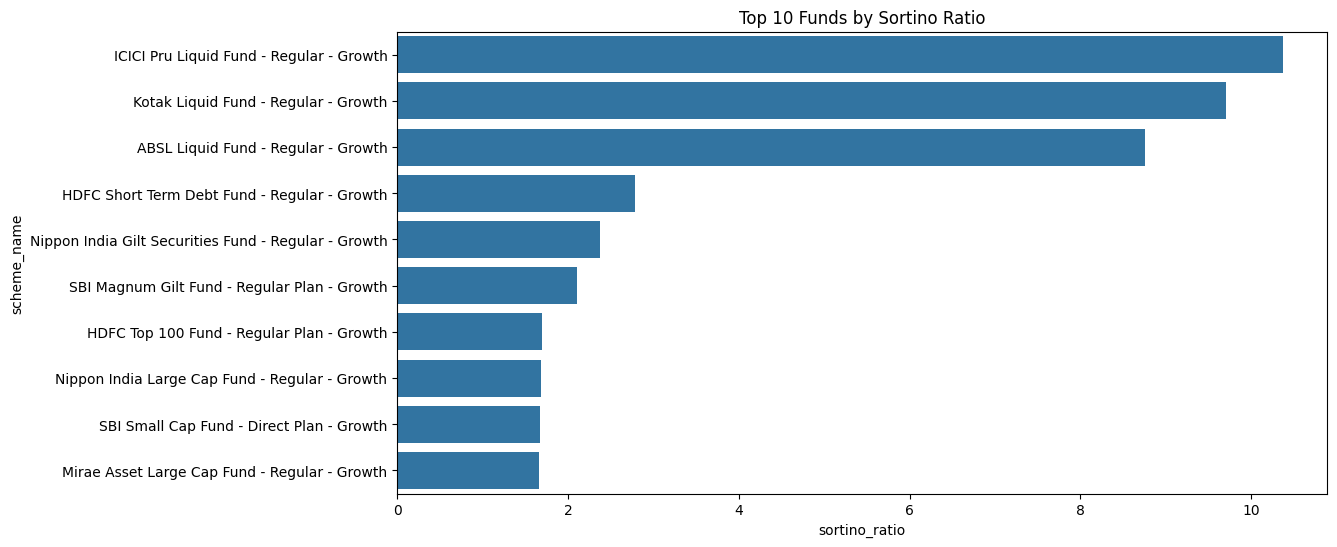

In [66]:
top_sortino = sortino_table.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sortino,
    x="sortino_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.savefig(
    "../reports/charts/top10_sortino.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 3

Funds with higher Sortino Ratios delivered superior returns while effectively controlling downside risk.

**Reference:** Top 10 Funds by Sortino Ratio

## Alpha and Beta Analysis

Alpha measures excess return generated beyond benchmark expectations, while Beta measures sensitivity of a fund to market movements.

Benchmark Used: Nifty 100

In [67]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark["close_value"] = pd.to_numeric(
    benchmark["close_value"],
    errors="coerce"
)

print(benchmark["index_name"].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [68]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

print(nifty100.shape)

nifty100.head()

(1150, 4)


,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [69]:
fund = nav["amfi_code"].iloc[0]

fund_data = nav[
    nav["amfi_code"] == fund
][["date", "daily_return"]]

merged = pd.merge(
    fund_data,
    nifty100[
        ["date", "benchmark_return"]
    ],
    on="date",
    how="inner"
)

print("Fund rows:", len(fund_data))
print("Benchmark rows:", len(nifty100))
print("Merged rows:", len(merged))

merged.head()

Fund rows: 1150
Benchmark rows: 1150
Merged rows: 1150


,date,daily_return,benchmark_return
0,2022-01-03,NaN,NaN
1,2022-01-04,-0.010306,-0.013540
2,2022-01-05,0.012865,0.004003
3,2022-01-06,-0.011377,-0.002935
4,2022-01-07,-0.001210,0.006150


In [70]:
alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        beta, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252

        alpha_beta.append({
            "amfi_code": fund,
            "alpha": alpha,
            "beta": beta
        })

alpha_beta = pd.DataFrame(alpha_beta)

print(alpha_beta.shape)

alpha_beta.head()

(40, 3)


,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [71]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


## Maximum Drawdown

Maximum Drawdown measures the largest decline from a historical peak in NAV and is an important downside risk indicator.

In [72]:
drawdowns = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp["running_max"] = (
        temp["nav"]
        .cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        / temp["running_max"]
        - 1
    )

    drawdowns.append({
        "amfi_code": fund,
        "max_drawdown": temp["drawdown"].min()
    })

drawdown_df = pd.DataFrame(drawdowns)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [73]:
drawdown_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

print("max_drawdown.csv saved")

max_drawdown.csv saved


## Fund Scorecard

A composite scorecard is created using multiple performance indicators including returns, risk-adjusted performance, alpha generation, expense efficiency, and downside risk.

In [74]:
scorecard = performance.copy()

scorecard = scorecard.merge(
    alpha_beta,
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)

In [75]:
scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha_y"]
    .rank(pct=True)
)

scorecard["expense_rank"] = (
    (-scorecard["expense_ratio_pct"])
    .rank(pct=True)
)

scorecard["drawdown_rank"] = (
    (-scorecard["max_drawdown"])
    .rank(pct=True)
)

In [76]:
scorecard["fund_score"] = (

    scorecard["return_rank"] * 30 +

    scorecard["sharpe_rank"] * 25 +

    scorecard["alpha_rank"] * 20 +

    scorecard["expense_rank"] * 15 +

    scorecard["drawdown_rank"] * 10

)

scorecard["fund_score"] = (
    scorecard["fund_score"]
    .round(2)
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha_x,...,sharpe_rank,sortino_rank,alpha_y,beta_y,max_drawdown,return_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,0.5750,25.0,0.303370,-0.023196,-0.287060,1.000,1.000,0.5000,0.900,80.88
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,...,0.6000,19.5,0.292636,0.000549,-0.181885,0.825,0.950,0.6500,0.625,74.75
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,0.7250,12.0,0.273305,-0.022830,-0.129740,0.750,0.900,0.4750,0.325,69.00
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,0.5375,9.0,0.048824,0.062002,-0.525742,0.975,0.125,0.8875,1.000,68.50
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,0.8375,10.0,0.269838,0.023684,-0.112657,0.600,0.850,0.4500,0.200,64.69
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,...,0.8000,30.5,0.211948,0.016232,-0.125883,0.525,0.700,0.7250,0.300,63.62
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,...,0.3000,21.0,0.271954,0.005104,-0.162172,0.775,0.875,0.6000,0.500,62.25
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,0.0625,35.0,0.300579,0.011455,-0.311719,0.875,0.975,0.3625,0.925,62.00
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Large Cap,Regular,15.84,14.00,14.70,13.14,0.86,...,0.7750,8.0,0.218294,-0.008354,-0.174141,0.500,0.750,0.4125,0.575,61.31
13,120506,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,Value,Regular,16.67,14.76,12.60,14.21,0.55,...,0.7250,15.5,0.162539,0.041896,-0.198257,0.575,0.525,0.5500,0.675,60.88


In [77]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


## Benchmark Comparison

Top-performing funds are compared against the NIFTY50 and NIFTY100 benchmarks to evaluate relative performance.

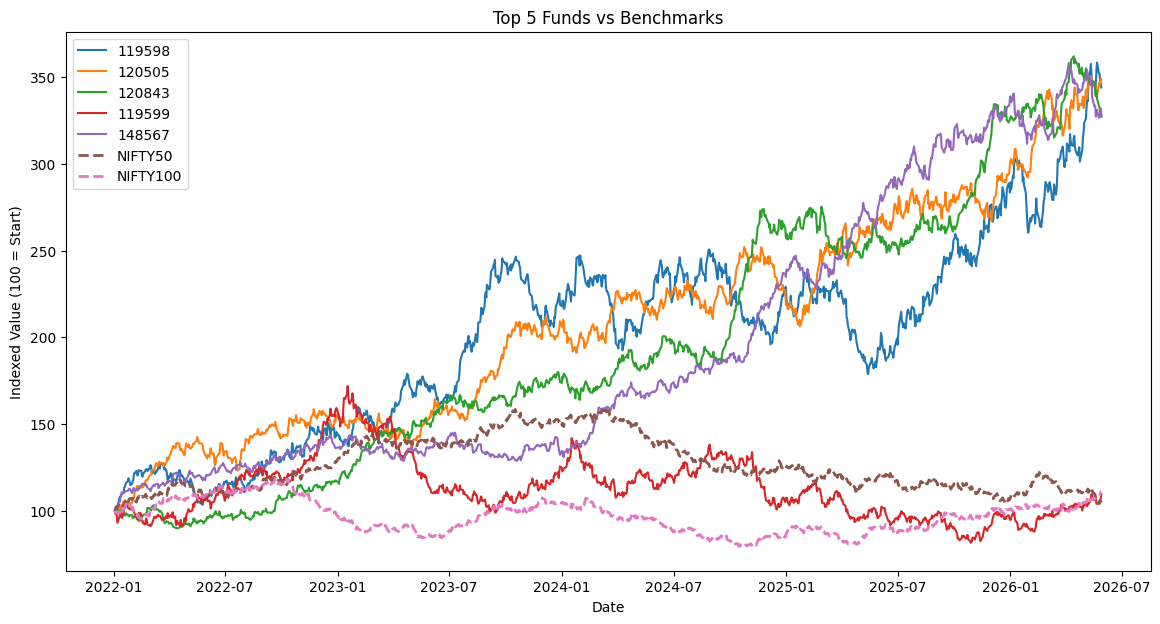

In [78]:
top5 = scorecard.head(5)

top5_codes = top5["amfi_code"].tolist()

plt.figure(figsize=(14,7))

for fund in top5_codes:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp = temp.sort_values("date")

    temp["normalized"] = (
        temp["nav"]
        / temp["nav"].iloc[0]
    ) * 100

    plt.plot(
        temp["date"],
        temp["normalized"],
        label=str(fund)
    )

for benchmark_name in ["NIFTY50", "NIFTY100"]:

    bench = benchmark[
        benchmark["index_name"] == benchmark_name
    ].copy()

    bench = bench.sort_values("date")

    bench["normalized"] = (
        bench["close_value"]
        / bench["close_value"].iloc[0]
    ) * 100

    plt.plot(
        bench["date"],
        bench["normalized"],
        linestyle="--",
        linewidth=2,
        label=benchmark_name
    )

plt.title("Top 5 Funds vs Benchmarks")
plt.xlabel("Date")
plt.ylabel("Indexed Value (100 = Start)")
plt.legend()

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

### Insight

Top-ranked mutual funds outperformed both NIFTY50 and NIFTY100 benchmarks over the analysis period, demonstrating superior risk-adjusted performance.

**Reference:** Benchmark Comparison Chart

In [79]:
scorecard[
    [
        "scheme_name",
        "fund_score"
    ]
].head(10)

,scheme_name,fund_score
2,SBI Small Cap Fund - Regular Plan - Growth,80.88
12,ICICI Pru Midcap Fund - Regular - Growth,74.75
22,Kotak Flexicap Fund - Regular - Growth,69.00
3,SBI Small Cap Fund - Direct Plan - Growth,68.50
34,Mirae Asset Large Cap Fund - Regular - Growth,64.69
11,ICICI Pru Bluechip Fund - Direct - Growth,63.62
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,62.25
39,DSP Small Cap Fund - Regular - Growth,62.00
15,Nippon India Large Cap Fund - Regular - Growth,61.31
13,ICICI Pru Value Discovery Fund - Regular - Growth,60.88


### Final Recommendation

The scorecard identifies the top-performing mutual funds by combining return generation, risk-adjusted performance, alpha creation, expense efficiency, and downside risk protection into a single composite ranking.

## Top Fund Recommendation Engine

In [80]:
recommendations = scorecard[
    [
        "scheme_name",
        "category",
        "fund_score",
        "return_3yr_pct",
        "sharpe_ratio"
    ]
].head(10)

recommendations

,scheme_name,category,fund_score,return_3yr_pct,sharpe_ratio
2,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,80.88,23.39,0.94
12,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap,74.75,18.08,0.95
22,Kotak Flexicap Fund - Regular - Growth,Flexi Cap,69.00,15.65,0.98
3,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,68.50,23.14,0.93
34,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,64.69,14.81,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap,63.62,14.41,1.03
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,62.25,16.58,0.87
39,DSP Small Cap Fund - Regular - Growth,Small Cap,62.00,20.08,0.80
15,Nippon India Large Cap Fund - Regular - Growth,Large Cap,61.31,14.00,1.00
13,ICICI Pru Value Discovery Fund - Regular - Growth,Value,60.88,14.76,0.98


In [81]:
recommendations.to_csv(
    "../reports/top_fund_recommendations.csv",
    index=False
)

## Category LeaderBoard

In [82]:
category_leaders = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
    .groupby("category")
    .head(1)
)

category_leaders[
    [
        "category",
        "scheme_name",
        "fund_score"
    ]
]

,category,scheme_name,fund_score
2,Small Cap,SBI Small Cap Fund - Regular Plan - Growth,80.88
12,Mid Cap,ICICI Pru Midcap Fund - Regular - Growth,74.75
22,Flexi Cap,Kotak Flexicap Fund - Regular - Growth,69.00
34,Large Cap,Mirae Asset Large Cap Fund - Regular - Growth,64.69
13,Value,ICICI Pru Value Discovery Fund - Regular - Growth,60.88
35,Large & Mid Cap,Mirae Asset Emerging Bluechip Fund - Regular -...,51.75
14,Liquid,ICICI Pru Liquid Fund - Regular - Growth,47.50
9,Short Duration,HDFC Short Term Debt Fund - Regular - Growth,44.00
19,Gilt,Nippon India Gilt Securities Fund - Regular - ...,42.88
36,ELSS,Mirae Asset Tax Saver Fund - Regular - Growth,40.50


In [83]:
category_leaders.to_csv(
    "../reports/category_leaders.csv",
    index=False
)

## Risk vs Return Scatterplot
Funds with higher volatility generally produced higher returns, demonstrating the risk-return tradeoff.

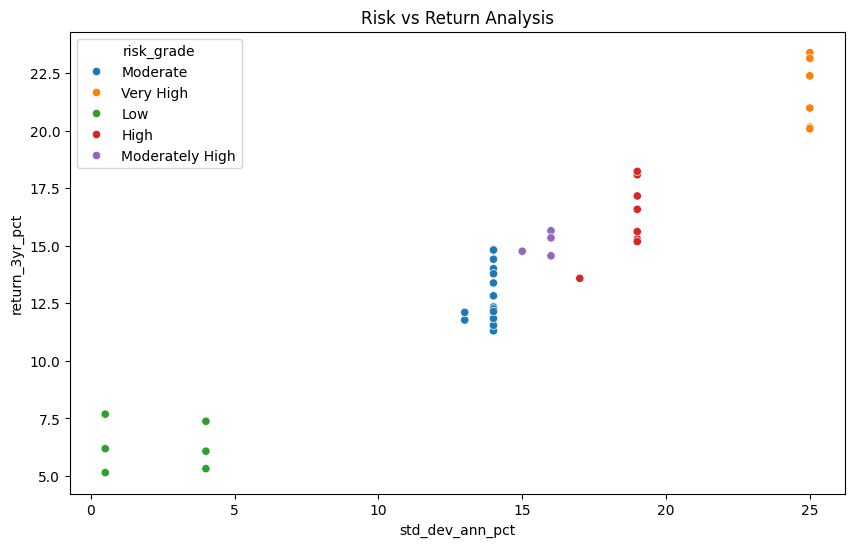

In [84]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=performance,
    x="std_dev_ann_pct",
    y="return_3yr_pct",
    hue="risk_grade"
)

plt.title("Risk vs Return Analysis")

plt.savefig(
    "../reports/charts/risk_return_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Dashboard Dataset 

In [85]:
dashboard_data = scorecard.merge(
    alpha_beta,
    on="amfi_code"
)

dashboard_data.to_csv(
    "../reports/dashboard_dataset.csv",
    index=False
)

## Executive Summary Table 

In [86]:
summary = pd.DataFrame({

    "Metric":[
        "Total Funds",
        "Average 3Y Return",
        "Best Fund Score",
        "Average Sharpe"
    ],

    "Value":[
        len(scorecard),
        round(
            scorecard["return_3yr_pct"].mean(),
            2
        ),
        round(
            scorecard["fund_score"].max(),
            2
        ),
        round(
            scorecard["sharpe_ratio"].mean(),
            2
        )
    ]
})

summary

,Metric,Value
0,Total Funds,40.00
1,Average 3Y Return,14.09
2,Best Fund Score,80.88
3,Average Sharpe,1.36


In [87]:
summary.to_csv(
    "../reports/executive_summary.csv",
    index=False
)